In [1]:
from Dataset.DataSetLoaders import ChessDataset
from ChessLens import ChessLensImage

import cv2
import numpy as np
import math
from matplotlib import pyplot as plt

from tqdm import tqdm

In [2]:
def normal_pdf(x, mean, std):
    return (1 / (std * math.sqrt(2 * math.pi))) * math.exp(-0.5 * ((x - mean)/std)**2)

def joint_log_probability(values, means, stds):
    log_prob = 0.0
    for x, mu, sigma in zip(values, means, stds):
        pdf = normal_pdf(x, mu, sigma)
        log_prob += math.log(pdf + 1e-6)
    return log_prob

def get_z(values, means, stds):
    probs = []

    for i in range(values.shape[0]):
        # probs.append(joint_log_probability(values[i], means, stds))
        probs.append((values[i] - means) / stds)
    
    probs = np.stack(probs, axis=0)
    return probs

In [3]:
ds = ChessDataset.ChessDataset(
    config={
        "img_size": (640,640)
    }
)

In [4]:
img_obj = ChessLensImage()

In [5]:
def get_hist(img, mask=None) -> np.ndarray:
    bins = 8

    hists = []

    for i in range(8):
        for j in range(8):
            tmp_img = img[i*32:(i+1)*32, j*32:(j+1)*32]
            hist_r = cv2.calcHist([tmp_img], [0], None, [bins], [0,256])
            hist_g = cv2.calcHist([tmp_img], [1], None, [bins], [0,256])
            hist_b = cv2.calcHist([tmp_img], [2], None, [bins], [0,256])
            # hist_r, _ = np.histogram(
            #     img[:, :, 0].ravel(), bins=bins, range=[0, 256])
            # hist_g, _ = np.histogram(
            #     img[:, :, 1].ravel(), bins=bins, range=[0, 256])
            # hist_b, _ = np.histogram(
            #     img[:, :, 2].ravel(), bins=bins, range=[0, 256])

            hist = np.concat([hist_r, hist_g, hist_b], axis=0)[:,0]
            # hist = hist / (img.shape[0]*img.shape[1])

            hists.append(hist)

    return np.stack(hists, axis=0)

In [6]:
hists = []
for img, y in tqdm(ds):
    try:
        img_np = (img.permute(1,2,0).cpu().numpy()*255).astype(np.uint8)
        img_obj.load_image(img)
        corners, cnf = img_obj.detect_board()
        # corners = corners.numpy().astype(np.int32)
        # mask = np.zeros(img.shape[1:], dtype=np.uint8)
        # cv2.fillConvexPoly(mask, corners, 255)

        warped, M = img_obj.warp()
        # img, M = img_obj.warp()
        # hist = get_hist(img_np, mask)
        hist = get_hist(warped)
        hists.append(hist)

    except Exception as e:
        # raise e
        pass
    # break

100%|██████████| 2005/2005 [02:45<00:00, 12.10it/s]


In [7]:
# hists = np.stack(hists, axis=0)
hists = np.concatenate(hists, axis=0)

hists_mean = hists.mean(axis=0)
hists_std = hists.std(axis=0)

In [8]:
hists.shape

(126336, 24)

In [9]:
hists_mean.shape, hists_std.shape

((24,), (24,))

In [10]:
hists_mean, hists_std

(array([     57.626,      152.51,      245.71,      49.019,      38.859,       51.95,      168.69,      259.62,      38.094,      59.772,      141.43,       104.4,      196.81,      79.277,      170.54,      233.66,      35.148,      67.456,      126.64,      247.22,      78.838,      103.13,      143.48,      222.06],
       dtype=float32),
 array([     139.71,      248.66,      329.94,      101.48,      50.672,      69.873,      278.58,       353.8,       90.32,      122.79,      274.21,       184.1,      294.32,      137.45,      282.78,      361.34,      88.307,       141.5,       242.5,      331.49,      142.03,      180.06,      264.25,      359.54],
       dtype=float32))

In [20]:
game_ds = ChessDataset.GameDataset(
    root_dirs="/mnt/D/University/Thesis_Dataset/Games/hands_data",
    config={
        "img_size": (640,640)
    }
)

In [22]:
labels = []
errs = []
for img, y in tqdm(game_ds):
    # y["frame_validity"] # valid/occlusion
    
    try:
        img_np = (img.permute(1,2,0).cpu().numpy()*255).astype(np.uint8)
        img_obj.load_image(img)
        corners, cnf = img_obj.detect_board()
        # corners = corners.numpy().astype(np.int32)
        # mask = np.zeros(img.shape[1:], dtype=np.uint8)
        # cv2.fillConvexPoly(mask, corners, 255)

        warped, M = img_obj.warp()
        # img, M = img_obj.warp()
        # hist = get_hist(img_np, mask)
        hist = get_hist(warped)

        labels.append(y["frame_validity"])
        # errs.append(joint_log_probability(hist, hists_mean, hists_std))
        errs.append(get_z(hist, hists_mean, hists_std))
    except Exception as e:
        raise e

100%|██████████| 201/201 [00:16<00:00, 12.20it/s]


In [23]:
labels= np.array([(1 if lbl == "occlusion" else 0) for lbl in labels])
# errs = np.array(errs)
errs = np.stack(errs, axis=0)
# errs *= -1

labels.shape, errs.shape

((201,), (201, 64, 24))

In [24]:
errs_modified = np.abs(errs).mean(axis=2)

In [31]:
N = 1
# extremes_mean = np.mean(np.partition(errs_modified, N, axis=1)[:, :N], axis=1)
extremes_mean = np.mean(np.partition(errs_modified, -N, axis=1)[:, -N:], axis=1)

extremes_mean.shape

(201,)

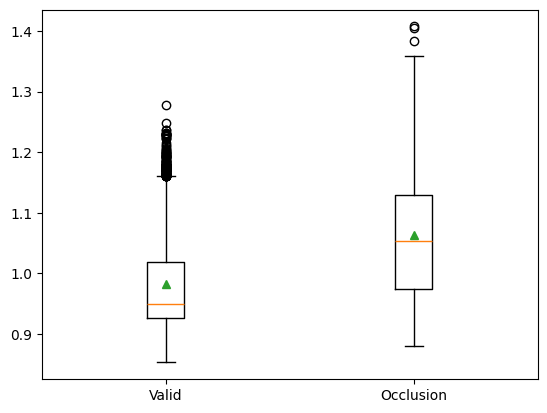

In [ ]:
plt.boxplot([extremes_mean[labels == 0], extremes_mean[labels == 1]], tick_labels=["Valid", "Occlusion"], showmeans=True);

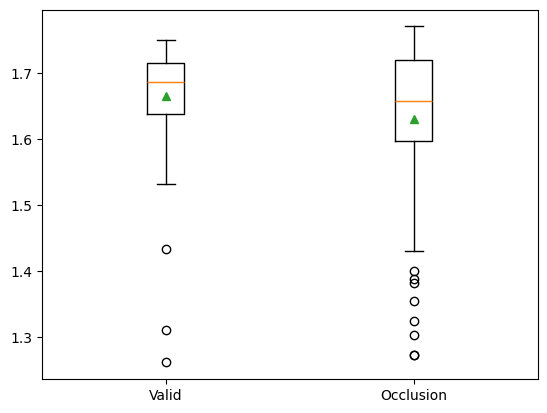

In [32]:
plt.boxplot([extremes_mean[labels == 0], extremes_mean[labels == 1]], tick_labels=["Valid", "Occlusion"], showmeans=True);

In [17]:
hists_mean

array([     57.626,      152.51,      245.71,      49.019,      38.859,       51.95,      168.69,      259.62,      38.094,      59.772,      141.43,       104.4,      196.81,      79.277,      170.54,      233.66,      35.148,      67.456,      126.64,      247.22,      78.838,      103.13,      143.48,      222.06],
      dtype=float32)